# 08 — Robustness: Noise and Missing Channels

Goal:
- Test how parameter recoverability degrades under controlled perturbations.
- Evaluate clean-train/noisy-test robustness.
- Evaluate noisy-train/noisy-test recovery.
- Test missing redshift slices and missing k-scale regions.

This notebook uses Random Forest regressors as fast diagnostic models.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS = PROJECT_ROOT / "results"
FIGURES = PROJECT_ROOT / "figures"

for path in [DATA_PROCESSED, RESULTS, FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression


In [3]:
DATA_TAG = "n100_validation"
RANDOM_SEED = 42

NOISE_LEVELS = [0.0, 0.1, 0.25, 0.5, 1.0]
N_TREES = 500

print("Data tag:", DATA_TAG)
print("Noise levels:", NOISE_LEVELS)

Data tag: n100_validation
Noise levels: [0.0, 0.1, 0.25, 0.5, 1.0]


In [4]:
X_raw = np.load(DATA_PROCESSED / f"feature_matrix_{DATA_TAG}.npy")
y_raw = np.load(DATA_PROCESSED / f"target_matrix_{DATA_TAG}.npy")

feature_names_df = pd.read_csv(DATA_PROCESSED / f"feature_names_{DATA_TAG}.csv")
target_names_df = pd.read_csv(DATA_PROCESSED / f"target_names_{DATA_TAG}.csv")

feature_names = feature_names_df["feature_name"].tolist()
target_names = target_names_df["target_name"].tolist()

split_data = np.load(DATA_PROCESSED / f"split_indices_{DATA_TAG}.npz")
train_indices = split_data["train_indices"]
test_indices = split_data["test_indices"]

X_train_raw = X_raw[train_indices]
X_test_raw = X_raw[test_indices]

y_train = y_raw[train_indices]
y_test = y_raw[test_indices]

print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)
print("Train:", X_train_raw.shape)
print("Test:", X_test_raw.shape)
print("Targets:", target_names)

X_raw: (100, 57)
y_raw: (100, 5)
Train: (80, 57)
Test: (20, 57)
Targets: ['zeta', 'log10_Tvir', 'R_mfp', 'log10_LX', 'sigma8']


In [5]:
assert X_raw.shape == (100, 57)
assert y_raw.shape == (100, 5)

assert X_train_raw.shape[0] == y_train.shape[0]
assert X_test_raw.shape[0] == y_test.shape[0]

assert len(feature_names) == X_raw.shape[1]
assert len(target_names) == y_raw.shape[1]

assert np.all(np.isfinite(X_raw))
assert np.all(np.isfinite(y_raw))

print("Validation passed.")

Validation passed.


In [6]:
def parse_feature_name(name):
    match = re.match(r"delta2_z([0-9.]+)_k([0-9.]+)", name)

    if match is None:
        raise ValueError(f"Could not parse feature name: {name}")

    z = float(match.group(1))
    k = float(match.group(2))

    return z, k


feature_meta_rows = []

for idx, name in enumerate(feature_names):
    z, k = parse_feature_name(name)

    feature_meta_rows.append({
        "feature_index": idx,
        "feature_name": name,
        "z": z,
        "k": k,
    })

feature_meta = pd.DataFrame(feature_meta_rows)

available_redshifts = sorted(feature_meta["z"].unique(), reverse=True)
available_k = sorted(feature_meta["k"].unique())

print("Available redshifts:", available_redshifts)
print("k bins:", len(available_k))
feature_meta.head()

Available redshifts: [np.float64(12.0), np.float64(10.0), np.float64(8.0)]
k bins: 19


,feature_index,feature_name,z,k
0,0,delta2_z12.0_k0.08491,12.0,0.08491
1,1,delta2_z12.0_k0.10379,12.0,0.10379
2,2,delta2_z12.0_k0.12686,12.0,0.12686
3,3,delta2_z12.0_k0.15507,12.0,0.15507
4,4,delta2_z12.0_k0.18954,12.0,0.18954


In [7]:
k_values = np.array(available_k)

k_low_cut = np.percentile(k_values, 33.3)
k_high_cut = np.percentile(k_values, 66.7)

def assign_k_group(k):
    if k <= k_low_cut:
        return "low_k"
    elif k <= k_high_cut:
        return "mid_k"
    else:
        return "high_k"

feature_meta["k_group"] = feature_meta["k"].apply(assign_k_group)

feature_meta.groupby("k_group").size()

k_group
high_k    18
low_k     18
mid_k     21
dtype: int64

In [8]:
def evaluate_predictions(y_true, y_pred, target_names, experiment, condition, noise_level=None):
    rows = []

    for i, target in enumerate(target_names):
        rows.append({
            "experiment": experiment,
            "condition": condition,
            "noise_level": noise_level,
            "target": target,
            "r2": r2_score(y_true[:, i], y_pred[:, i]),
            "mae": mean_absolute_error(y_true[:, i], y_pred[:, i]),
        })

    return rows

In [9]:
def train_rf_predict(X_train_raw_input, X_test_raw_input, y_train_input):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_raw_input)
    X_test_scaled = scaler.transform(X_test_raw_input)

    model = RandomForestRegressor(
        n_estimators=N_TREES,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    model.fit(X_train_scaled, y_train_input)

    y_pred = model.predict(X_test_scaled)

    return y_pred, model, scaler

In [10]:
def add_relative_gaussian_noise(X, noise_level, random_seed):
    """
    Adds feature-wise relative Gaussian noise.

    noise_level = 0.1 means noise std is 10% of each feature's training-set std.
    """

    rng = np.random.default_rng(random_seed)

    X = np.asarray(X, dtype=float)

    feature_std = np.std(X_train_raw, axis=0)
    feature_std = np.where(feature_std == 0, 1.0, feature_std)

    noise = rng.normal(
        loc=0.0,
        scale=noise_level * feature_std,
        size=X.shape,
    )

    X_noisy = X + noise

    X_noisy = np.clip(X_noisy, a_min=0.0, a_max=None)

    return X_noisy

In [11]:
robustness_rows = []

clean_pred, clean_model, clean_scaler = train_rf_predict(
    X_train_raw_input=X_train_raw,
    X_test_raw_input=X_test_raw,
    y_train_input=y_train,
)

robustness_rows.extend(
    evaluate_predictions(
        y_true=y_test,
        y_pred=clean_pred,
        target_names=target_names,
        experiment="baseline_clean",
        condition="clean_train_clean_test",
        noise_level=0.0,
    )
)

baseline_clean_results = pd.DataFrame(robustness_rows)

baseline_clean_results

,experiment,condition,noise_level,target,r2,mae
0,baseline_clean,clean_train_clean_test,0.0,zeta,-0.184709,16.376111
1,baseline_clean,clean_train_clean_test,0.0,log10_Tvir,0.047715,0.384969
2,baseline_clean,clean_train_clean_test,0.0,R_mfp,0.139587,5.026085
3,baseline_clean,clean_train_clean_test,0.0,log10_LX,-0.065255,0.986001
4,baseline_clean,clean_train_clean_test,0.0,sigma8,0.808639,0.017444


In [12]:
for noise_level in NOISE_LEVELS:

    X_test_noisy = add_relative_gaussian_noise(
        X_test_raw,
        noise_level=noise_level,
        random_seed=RANDOM_SEED + int(noise_level * 1000),
    )

    X_test_noisy_scaled = clean_scaler.transform(X_test_noisy)

    y_pred_noisy = clean_model.predict(X_test_noisy_scaled)

    robustness_rows.extend(
        evaluate_predictions(
            y_true=y_test,
            y_pred=y_pred_noisy,
            target_names=target_names,
            experiment="noise_robustness",
            condition="clean_train_noisy_test",
            noise_level=noise_level,
        )
    )

print("Clean-train/noisy-test robustness complete.")

Clean-train/noisy-test robustness complete.


In [13]:
for noise_level in NOISE_LEVELS:

    X_train_noisy = add_relative_gaussian_noise(
        X_train_raw,
        noise_level=noise_level,
        random_seed=RANDOM_SEED + 10_000 + int(noise_level * 1000),
    )

    X_test_noisy = add_relative_gaussian_noise(
        X_test_raw,
        noise_level=noise_level,
        random_seed=RANDOM_SEED + 20_000 + int(noise_level * 1000),
    )

    y_pred_noisy_train, _, _ = train_rf_predict(
        X_train_raw_input=X_train_noisy,
        X_test_raw_input=X_test_noisy,
        y_train_input=y_train,
    )

    robustness_rows.extend(
        evaluate_predictions(
            y_true=y_test,
            y_pred=y_pred_noisy_train,
            target_names=target_names,
            experiment="noise_robustness",
            condition="noisy_train_noisy_test",
            noise_level=noise_level,
        )
    )

print("Noisy-train/noisy-test robustness complete.")

Noisy-train/noisy-test robustness complete.


In [14]:
robustness_results = pd.DataFrame(robustness_rows)

robustness_results.head()

,experiment,condition,noise_level,target,r2,mae
0,baseline_clean,clean_train_clean_test,0.0,zeta,-0.184709,16.376111
1,baseline_clean,clean_train_clean_test,0.0,log10_Tvir,0.047715,0.384969
2,baseline_clean,clean_train_clean_test,0.0,R_mfp,0.139587,5.026085
3,baseline_clean,clean_train_clean_test,0.0,log10_LX,-0.065255,0.986001
4,baseline_clean,clean_train_clean_test,0.0,sigma8,0.808639,0.017444


In [15]:
noise_results_path = RESULTS / f"noise_robustness_results_{DATA_TAG}.csv"

robustness_results.to_csv(noise_results_path, index=False)

print("Saved noise robustness results to:", noise_results_path)

Saved noise robustness results to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/noise_robustness_results_n100_validation.csv


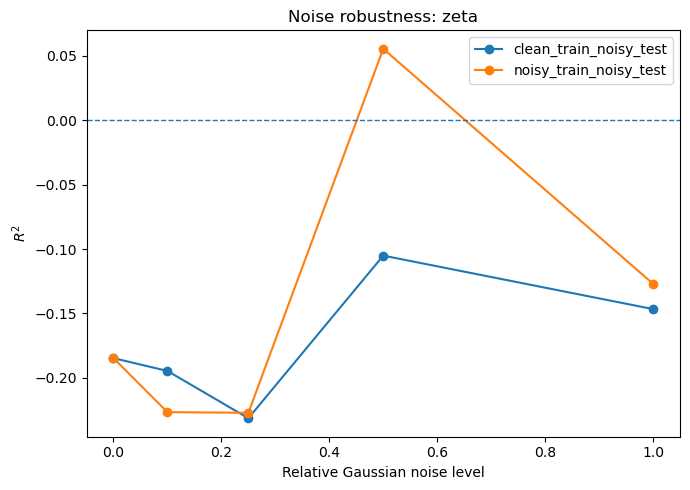

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/noise_robustness_zeta_n100_validation.png


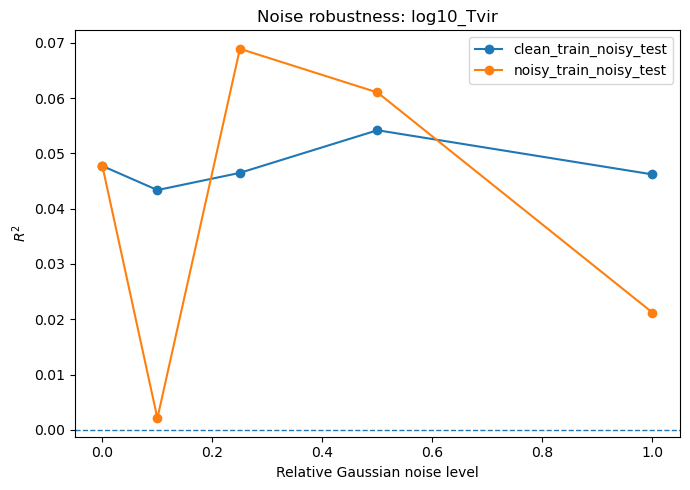

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/noise_robustness_log10_Tvir_n100_validation.png


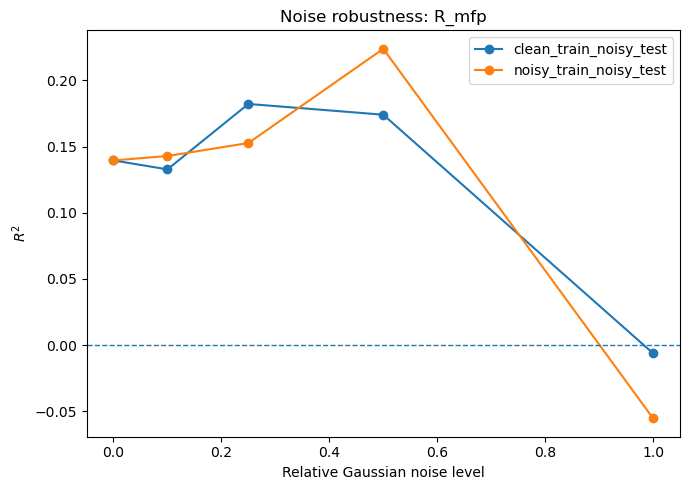

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/noise_robustness_R_mfp_n100_validation.png


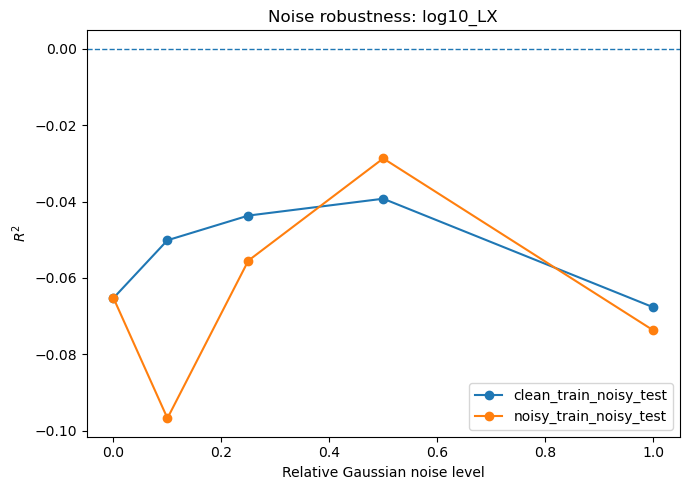

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/noise_robustness_log10_LX_n100_validation.png


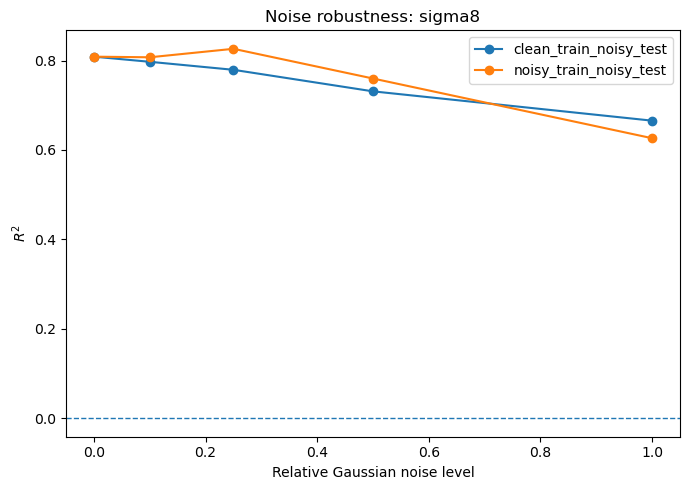

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/noise_robustness_sigma8_n100_validation.png


In [16]:
noise_plot_df = robustness_results[
    robustness_results["experiment"] == "noise_robustness"
].copy()

for target in target_names:
    plt.figure(figsize=(7, 5))

    for condition in ["clean_train_noisy_test", "noisy_train_noisy_test"]:
        sub = noise_plot_df[
            (noise_plot_df["target"] == target)
            & (noise_plot_df["condition"] == condition)
        ].sort_values("noise_level")

        plt.plot(
            sub["noise_level"],
            sub["r2"],
            marker="o",
            label=condition,
        )

    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Relative Gaussian noise level")
    plt.ylabel(r"$R^2$")
    plt.title(f"Noise robustness: {target}")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES / f"noise_robustness_{target}_{DATA_TAG}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print("Saved:", out_path)

In [17]:
clean_noisy = noise_plot_df[
    noise_plot_df["condition"] == "clean_train_noisy_test"
].copy()

noise_heatmap = clean_noisy.pivot_table(
    index="target",
    columns="noise_level",
    values="r2",
)

noise_heatmap = noise_heatmap[NOISE_LEVELS]

noise_heatmap

noise_level,0.00,0.10,0.25,0.50,1.00
target,,,,,
R_mfp,0.139587,0.132819,0.182272,0.174129,-0.006172
log10_LX,-0.065255,-0.050129,-0.043667,-0.039253,-0.067651
log10_Tvir,0.047715,0.043358,0.046472,0.054177,0.046189
sigma8,0.808639,0.797168,0.779251,0.731064,0.665518
zeta,-0.184709,-0.194636,-0.231357,-0.105107,-0.146610


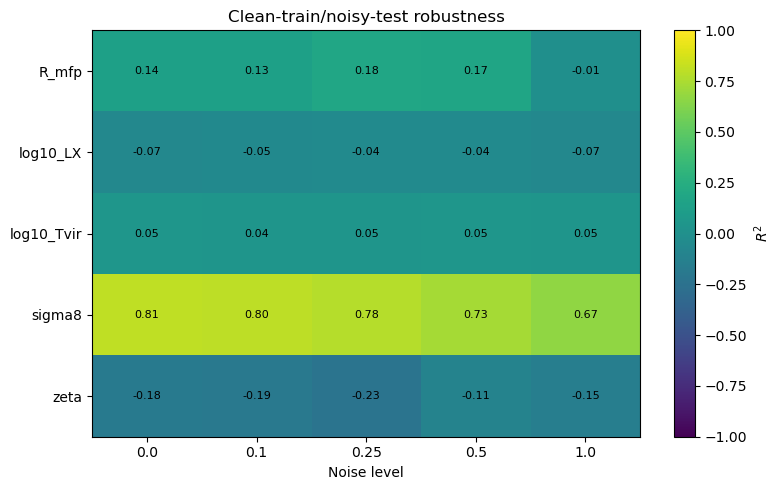

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/noise_robustness_heatmap_n100_validation.png


In [18]:
plt.figure(figsize=(8, 5))

im = plt.imshow(noise_heatmap.values, aspect="auto", vmin=-1, vmax=1)

plt.xticks(
    ticks=np.arange(len(NOISE_LEVELS)),
    labels=[str(x) for x in NOISE_LEVELS],
)

plt.yticks(
    ticks=np.arange(len(noise_heatmap.index)),
    labels=noise_heatmap.index,
)

plt.colorbar(im, label=r"$R^2$")
plt.xlabel("Noise level")
plt.title("Clean-train/noisy-test robustness")

for i in range(noise_heatmap.shape[0]):
    for j in range(noise_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{noise_heatmap.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.tight_layout()

noise_heatmap_path = FIGURES / f"noise_robustness_heatmap_{DATA_TAG}.png"
plt.savefig(noise_heatmap_path, dpi=300)
plt.show()

print("Saved figure to:", noise_heatmap_path)

In [19]:
missing_rows = []

for z_missing in available_redshifts:

    keep_indices = feature_meta.loc[
        feature_meta["z"] != z_missing,
        "feature_index"
    ].to_numpy()

    X_train_subset = X_train_raw[:, keep_indices]
    X_test_subset = X_test_raw[:, keep_indices]

    y_pred_missing, _, _ = train_rf_predict(
        X_train_raw_input=X_train_subset,
        X_test_raw_input=X_test_subset,
        y_train_input=y_train,
    )

    missing_rows.extend(
        evaluate_predictions(
            y_true=y_test,
            y_pred=y_pred_missing,
            target_names=target_names,
            experiment="missing_redshift",
            condition=f"missing_z_{z_missing:.1f}",
            noise_level=None,
        )
    )

print("Missing redshift tests complete.")

Missing redshift tests complete.


In [20]:
for k_group_missing in ["low_k", "mid_k", "high_k"]:

    keep_indices = feature_meta.loc[
        feature_meta["k_group"] != k_group_missing,
        "feature_index"
    ].to_numpy()

    X_train_subset = X_train_raw[:, keep_indices]
    X_test_subset = X_test_raw[:, keep_indices]

    y_pred_missing, _, _ = train_rf_predict(
        X_train_raw_input=X_train_subset,
        X_test_raw_input=X_test_subset,
        y_train_input=y_train,
    )

    missing_rows.extend(
        evaluate_predictions(
            y_true=y_test,
            y_pred=y_pred_missing,
            target_names=target_names,
            experiment="missing_k_group",
            condition=f"missing_{k_group_missing}",
            noise_level=None,
        )
    )

print("Missing k-scale tests complete.")

Missing k-scale tests complete.


In [21]:
missing_results = pd.DataFrame(missing_rows)

missing_results.head()

,experiment,condition,noise_level,target,r2,mae
0,missing_redshift,missing_z_12.0,None,zeta,-0.079547,15.579723
1,missing_redshift,missing_z_12.0,None,log10_Tvir,0.006807,0.392373
2,missing_redshift,missing_z_12.0,None,R_mfp,0.131600,5.114059
3,missing_redshift,missing_z_12.0,None,log10_LX,-0.048221,0.978901
4,missing_redshift,missing_z_12.0,None,sigma8,0.853243,0.015343


In [22]:
missing_results_path = RESULTS / f"missing_channel_results_{DATA_TAG}.csv"

missing_results.to_csv(missing_results_path, index=False)

print("Saved missing-channel results to:", missing_results_path)

Saved missing-channel results to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/missing_channel_results_n100_validation.csv


In [23]:
missing_redshift_results = missing_results[
    missing_results["experiment"] == "missing_redshift"
].copy()

missing_redshift_heatmap = missing_redshift_results.pivot_table(
    index="target",
    columns="condition",
    values="r2",
)

missing_redshift_heatmap

condition,missing_z_10.0,missing_z_12.0,missing_z_8.0
target,,,
R_mfp,0.174479,0.131600,-0.014867
log10_LX,-0.087015,-0.048221,-0.114213
log10_Tvir,0.040154,0.006807,0.040401
sigma8,0.720137,0.853243,0.859304
zeta,-0.263495,-0.079547,-0.171516


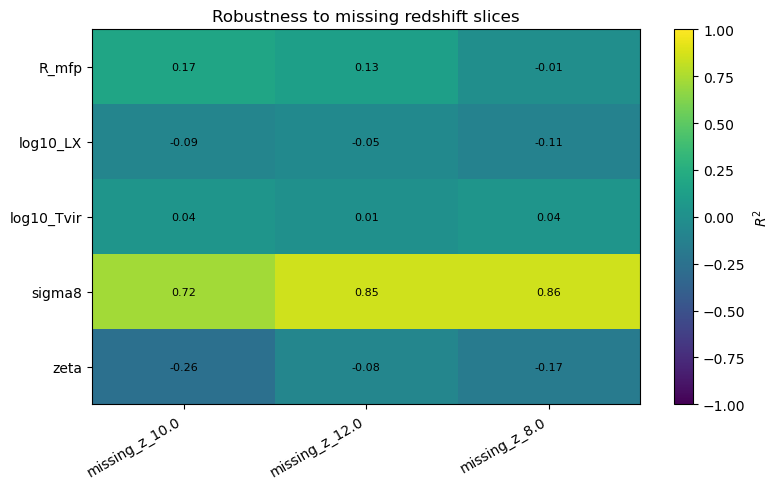

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/missing_redshift_heatmap_n100_validation.png


In [24]:
plt.figure(figsize=(8, 5))

im = plt.imshow(missing_redshift_heatmap.values, aspect="auto", vmin=-1, vmax=1)

plt.xticks(
    ticks=np.arange(len(missing_redshift_heatmap.columns)),
    labels=missing_redshift_heatmap.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=np.arange(len(missing_redshift_heatmap.index)),
    labels=missing_redshift_heatmap.index,
)

plt.colorbar(im, label=r"$R^2$")
plt.title("Robustness to missing redshift slices")

for i in range(missing_redshift_heatmap.shape[0]):
    for j in range(missing_redshift_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{missing_redshift_heatmap.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.tight_layout()

missing_redshift_heatmap_path = FIGURES / f"missing_redshift_heatmap_{DATA_TAG}.png"
plt.savefig(missing_redshift_heatmap_path, dpi=300)
plt.show()

print("Saved figure to:", missing_redshift_heatmap_path)

In [25]:
missing_k_results = missing_results[
    missing_results["experiment"] == "missing_k_group"
].copy()

missing_k_heatmap = missing_k_results.pivot_table(
    index="target",
    columns="condition",
    values="r2",
)

missing_k_heatmap

condition,missing_high_k,missing_low_k,missing_mid_k
target,,,
R_mfp,0.164348,0.022068,0.167555
log10_LX,-0.098915,-0.100934,-0.068821
log10_Tvir,0.057911,0.058897,0.014376
sigma8,0.782950,0.921355,0.796210
zeta,-0.245367,-0.430521,-0.129231


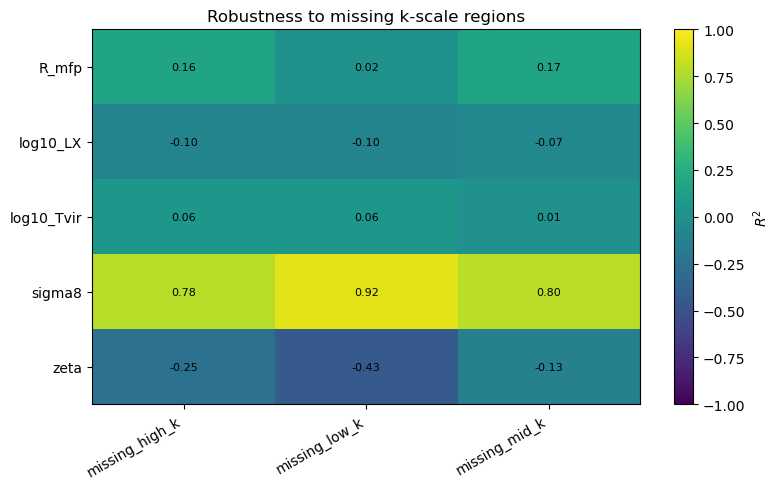

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/missing_k_heatmap_n100_validation.png


In [26]:
plt.figure(figsize=(8, 5))

im = plt.imshow(missing_k_heatmap.values, aspect="auto", vmin=-1, vmax=1)

plt.xticks(
    ticks=np.arange(len(missing_k_heatmap.columns)),
    labels=missing_k_heatmap.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=np.arange(len(missing_k_heatmap.index)),
    labels=missing_k_heatmap.index,
)

plt.colorbar(im, label=r"$R^2$")
plt.title("Robustness to missing k-scale regions")

for i in range(missing_k_heatmap.shape[0]):
    for j in range(missing_k_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{missing_k_heatmap.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.tight_layout()

missing_k_heatmap_path = FIGURES / f"missing_k_heatmap_{DATA_TAG}.png"
plt.savefig(missing_k_heatmap_path, dpi=300)
plt.show()

print("Saved figure to:", missing_k_heatmap_path)

In [27]:
robustness_metadata = {
    "notebook": "08_robustness_noise_missing_channels.ipynb",
    "data_tag": DATA_TAG,
    "model": "RandomForestRegressor",
    "n_samples": int(X_raw.shape[0]),
    "n_train": int(X_train_raw.shape[0]),
    "n_test": int(X_test_raw.shape[0]),
    "n_features": int(X_raw.shape[1]),
    "target_names": target_names,
    "noise_levels": NOISE_LEVELS,
    "available_redshifts": available_redshifts,
    "k_low_cut": float(k_low_cut),
    "k_high_cut": float(k_high_cut),
    "notes": (
        "Controlled robustness diagnostics using Gaussian perturbations, "
        "missing redshift slices, and missing k-scale regions. Results are "
        "exploratory for n=100 and should guide larger-scale production runs."
    ),
}

robustness_metadata_path = RESULTS / f"robustness_metadata_{DATA_TAG}.json"

with open(robustness_metadata_path, "w") as f:
    json.dump(robustness_metadata, f, indent=2)

print("Saved metadata to:", robustness_metadata_path)

Saved metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/robustness_metadata_n100_validation.json


In [28]:
print("=" * 60)
print("Notebook 08 completed successfully.")
print("=" * 60)

print("Dataset tag:", DATA_TAG)
print("Noise robustness rows:", len(robustness_results))
print("Missing-channel rows:", len(missing_results))

print("\nSaved files:")
print(" -", noise_results_path)
print(" -", missing_results_path)
print(" -", noise_heatmap_path)
print(" -", missing_redshift_heatmap_path)
print(" -", missing_k_heatmap_path)
print(" -", robustness_metadata_path)

Notebook 08 completed successfully.
Dataset tag: n100_validation
Noise robustness rows: 55
Missing-channel rows: 30

Saved files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/noise_robustness_results_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/missing_channel_results_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/noise_robustness_heatmap_n100_validation.png
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/missing_redshift_heatmap_n100_validation.png
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/missing_k_heatmap_n100_validation.png
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/robustness_metadata_n100_validation.json
